<a href="https://colab.research.google.com/github/ArtyomShabunin/SMOPA-26/blob/main/lesson_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://prana-system.com/files/110/rds_color_full.png" alt="tot image" width="300"  align="center"/> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img src="https://mpei.ru/AboutUniverse/OficialInfo/Attributes/PublishingImages/logo1.jpg" alt="mpei image" width="200" align="center"/>
<img src="https://mpei.ru/Structure/Universe/tanpe/structure/tfhe/PublishingImages/tot.png" alt="tot image" width="100"  align="center"/>

---

# **Системы машинного обучения и предиктивной аналитики в тепловой и возобновляемой энергетике**  

# ***Практические занятия***


---

# Занятие №10
# XGBoost
**22 апреля 2025г.**

XGBoost (Extreme Gradient Boosting) — это мощная и эффективная библиотека машинного обучения, основанная на методе **градиентного бустинга**. Она используется для решения задач классификации, регрессии и ранжирования.  

**Градиентный бустинг** — это техника **машинного обучения** для построения прогностических моделей. Она относится к классу **ансамблевых методов**, где несколько «слабых» моделей (обычно деревьев решений) объединяются в одну «сильную» модель.

Основная идея — строить модели **последовательно**, каждая из которых пытается **исправить ошибки** предыдущих, используя **градиентный спуск** для минимизации функции потерь.

### Основные особенности XGBoost:
- **Градиентный бустинг** — это метод ансамблирования, при котором несколько слабых моделей (обычно деревьев решений) объединяются для формирования сильной модели.
- **Эффективность** — XGBoost оптимизирован по скорости и использует продвинутые техники, такие как параллельные вычисления и буферизацию деревьев.
- **Поддержка регуляризации** — встроенная L1 и L2 регуляризация помогает предотвращать переобучение.
- **Обработка пропущенных значений** — библиотека умеет сама "угадывать", куда направить пропущенные значения при обучении деревьев.
- **Гибкость** — поддерживает различные типы задач, множество гиперпараметров, и может работать как с небольшими, так и с очень большими наборами данных.

### Где используется:
- Соревнования по машинному обучению (например, Kaggle)
- Финансовый анализ
- Диагностика в медицине
- Предиктивное обслуживание оборудования
- Маркетинговая аналитика

Cписок популярных альтернатив XGBoost — градиентного бустинга на решающих деревьях

1. **LightGBM (Microsoft)**
   - Быстрее XGBoost на больших данных.
   - Использует histogram-based алгоритм и leaf-wise рост дерева.
   - Хорош для задач с большим количеством признаков и категориальными данными.

2. **CatBoost (Yandex)**
   - Хорошо работает с категориальными признаками без необходимости one-hot encoding.
   - Снижает переобучение.
   - Прост в использовании: меньше параметров для настройки.

3. **HistGradientBoosting (sklearn)**
   - Встроенная реализация бустинга с гистограммами в Scikit-learn (`sklearn.ensemble.HistGradientBoostingClassifier/Regressor`).
   - Быстрый и поддерживает natively missing values.
   - Хорошая альтернатива без установки сторонних библиотек.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.preprocessing import LabelEncoder

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

import xgboost as xgb


## Многоклассовая классификация с XGBoost
### Загрузка и предобработка данных

In [2]:
# import gdown
# import warnings
# warnings.filterwarnings('ignore')
# gdown.download('https://drive.google.com/uc?id=1j54o4pHTm3HvaYTEtv_i4hOJGy5yNeZZ', verify=False)

data = pd.read_parquet("./data_modes.gzip")

In [3]:
data.head()

,GTA1.DBinPU.Aldi,GTA1.DBinPU.Alvna,GTA1.DBinPU.Alzzo,GTA1.DBinPU.Bo,GTA1.DBinPU.DlPkf,GTA1.DBinPU.DlPtgft,GTA1.DBinPU.DlPvf,GTA1.DBinPU.fi,GTA1.DBinPU.hmGTD,GTA1.DBinPU.hmTG,...,increas_power_mode,decreas_power_mode,start_up_mode,shutdown_mode,stopped_state_mode,air_heating_mode,active_target_mode_count,target_is_conflict,target_is_unknown,target
2023-02-26 06:59:50,225.550000,-4.398000,-0.082000,101.044,113.088000,33.709000,0.200000,56.615000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:00,225.610769,-4.327115,-0.089769,101.044,113.151231,33.709000,0.200000,56.615000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:10,225.436897,-4.363724,-0.091000,101.044,113.039759,33.633586,0.200207,56.516103,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:20,225.710833,-4.306625,-0.093000,101.044,113.053458,33.506500,0.200750,56.376000,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode
2023-02-26 07:00:30,226.355000,-4.183118,-0.091500,101.044,113.730941,33.818529,0.200000,56.199353,442.64,444.536,...,False,False,False,False,False,False,1,False,False,full_power_mode


Признаки

In [4]:
use_columns = ['GTA1.DBinPU.Alzzo', 'GTA1.DBinPU.Bo', 'GTA1.DBinPU.DlPkf',
               'GTA1.DBinPU.DlPtgft', 'GTA1.DBinPU.DlPvf', 'GTA1.DBinPU.fi',
               'GTA1.DBinPU.hmGTD', 'GTA1.DBinPU.hmTG', 'GTA1.DBinPU.P1mvhTG',
               'GTA1.DBinPU.Pk', 'GTA1.DBinPU.Pmvh', 'GTA1.DBinPU.PmvhMOGTD',
               'GTA1.DBinPU.PmvhMOTG', 'GTA1.DBinPU.PmvyhMOGTD',
               'GTA1.DBinPU.PmvyhMOTG', 'GTA1.DBinPU.Prazrjag_navhode',
               'GTA1.DBinPU.Ptgpd', 'GTA1.DBinPU.Ptgvh', 'GTA1.DBinPU.Pvh',
               'GTA1.DBinPU.Pvyhlg', 'GTA1.DBinPU.Qtg', 'GTA1.DBinPU.Tk',
               'GTA1.DBinPU.Tn', 'GTA1.DBinPU.Tt', 'GTA1.DBinPU.Tvh1',
               'GTA1.DBinPU.Pzad']

X = data.loc[:,use_columns]

Целевая переменная

In [5]:
data['target'] = data[[
    'full_power_mode', 'partial_power_mode',
    'increas_power_mode', 'decreas_power_mode', 'start_up_mode',
    'shutdown_mode', 'stopped_state_mode']].idxmax(axis=1)
y = data.loc[:, ['target']]

In [6]:
y.value_counts()

target            
full_power_mode       1045103
stopped_state_mode      26614
partial_power_mode       9547
shutdown_mode             347
start_up_mode             275
increas_power_mode        109
decreas_power_mode        103
Name: count, dtype: int64

Разделение на тестовую и тренировочную выборки

In [7]:
from sklearn.model_selection import train_test_split
# Разделяем с учетом дисбаланса классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
y_train.value_counts()

target            
full_power_mode       836082
stopped_state_mode     21291
partial_power_mode      7638
shutdown_mode            278
start_up_mode            220
increas_power_mode        87
decreas_power_mode        82
Name: count, dtype: int64

In [9]:
y_test.value_counts()

target            
full_power_mode       209021
stopped_state_mode      5323
partial_power_mode      1909
shutdown_mode             69
start_up_mode             55
increas_power_mode        22
decreas_power_mode        21
Name: count, dtype: int64

Балансировка данных (только train)


In [10]:
# !python -m pip install imbalanced-learn xgboost


Undersampling train


In [11]:
y_train_raw = y_train.squeeze()
y_test_eval = y_test.squeeze().copy()

sampling_strategy = {
    "full_power_mode": 1000,
    "stopped_state_mode": 1000,
    "partial_power_mode": 1000,
}
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train_raw)


In [12]:
pd.Series(y_train_resampled, name='target').value_counts()


target
full_power_mode       1000
partial_power_mode    1000
stopped_state_mode    1000
shutdown_mode          278
start_up_mode          220
increas_power_mode      87
decreas_power_mode      82
Name: count, dtype: int64

In [13]:
# Тестовую выборку НЕ ресемплируем, чтобы метрики отражали реальное распределение классов
y_test_eval.value_counts()


target
full_power_mode       209021
stopped_state_mode      5323
partial_power_mode      1909
shutdown_mode             69
start_up_mode             55
increas_power_mode        22
decreas_power_mode        21
Name: count, dtype: int64

In [14]:
X_test_eval = X_test.copy()
X_test_eval.shape, y_test_eval.shape


((216420, 26), (216420,))

Oversampling train


In [15]:
X_train_resampled, y_train_resampled = SMOTE(random_state=42).fit_resample(
    X_train_resampled, y_train_resampled
)


In [16]:
pd.Series(y_train_resampled, name='target').value_counts()


target
decreas_power_mode    1000
full_power_mode       1000
increas_power_mode    1000
partial_power_mode    1000
shutdown_mode         1000
start_up_mode         1000
stopped_state_mode    1000
Name: count, dtype: int64

XGBoost — это алгоритм на базе деревьев решений. А деревья решений и бустинг на их основе **не чувствительны к масштабу признаков** (в отличие от моделей типа линейной регрессии, SVM или нейронных сетей).

In [17]:
X_train_resampled.shape, X_test_eval.shape


((7000, 26), (216420, 26))

LabelEncoding (fit только на train labels)


In [18]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_raw)
y_test_eval_encoded = encoder.transform(y_test_eval)


In [19]:
y_train_resampled_encoded = encoder.transform(y_train_resampled)


In [20]:
y_test_eval_encoded[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [21]:
encoder.classes_


array(['decreas_power_mode', 'full_power_mode', 'increas_power_mode',
       'partial_power_mode', 'shutdown_mode', 'start_up_mode',
       'stopped_state_mode'], dtype=object)

### Инициализация и обучение модели

In [22]:
# xgboost импортирован в первом кодовом блоке


`xgb.XGBClassifier` — это класс из библиотеки **XGBoost**, предназначенный для решения **задач классификации** с помощью алгоритма **градиентного бустинга на деревьях решений**.

- строит ансамбль деревьев решений (по умолчанию — деревья классификации),
- на каждом шаге добавляет дерево, которое исправляет ошибки предыдущих,
- минимизирует выбранную **функцию потерь (objective)**.

---

**Применяется для:**

- **Бинарной классификации** (например, "да/нет", "спам/не спам")
- **Многоклассовой классификации** (например, классификация цифр, видов растений и т.д.)

---

Параметр **`objective`** в XGBoost `XGBClassifier` определяет **функцию потерь**, которую оптимизирует модель, и напрямую зависит от типа задачи — классификация, регрессия, ранжирование и т.д.


---

**Для задач многоклассовой классификации:**

- `'multi:softmax'` — многоклассовая классификация, возвращает **номер класса** напрямую.  
  Требуется параметр `num_class`.
- `'multi:softprob'` — многоклассовая классификация, возвращает **вектор вероятностей по каждому классу**.  
  Также требует `num_class`.

---

**Описание остальных гиперпараметров:**

- **`num_class=7`**  
  Количество уникальных классов в задаче классификации. В данном случае — 7 классов.

- **`max_depth=6`**  
  Максимальная глубина каждого дерева.  
  Глубокие деревья могут моделировать сложные зависимости, но также повышают риск переобучения.

- **`learning_rate=0.1`**
  Скорость обучения, понижает вклад каждого дерева в итоговое решение.  
  Меньшие значения требуют больше деревьев (`n_estimators`) для хорошей сходимости.

- **`n_estimators=100`**  
  Количество деревьев (итераций бустинга).  
  Итоговая модель будет объединением этих 100 слабых моделей.

- **`subsample=0.8`**  
  Доля случайно выбранных объектов для обучения каждого дерева.  
  Значения <1.0 могут помочь в борьбе с переобучением.

- **`colsample_bytree=0.8`**  
  Доля случайно выбранных признаков, используемых при построении каждого дерева.  
  Также снижает риск переобучения, особенно при большом числе признаков.

- **`random_state=42`**  
  Фиксирует генератор случайных чисел, обеспечивая воспроизводимость результатов.


In [23]:
classifier = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
)

classifier.fit(X_train_resampled, y_train_resampled_encoded)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [24]:
y_pred_base = classifier.predict(X_test_eval)


In [25]:
y_pred_base


array([1, 1, 1, ..., 1, 1, 6], shape=(216420,))

In [26]:
classifier.predict_proba(X_test_eval)[:3]


array([[6.7111659e-03, 9.5944160e-01, 3.1125724e-02, 7.5576146e-04,
        5.7998736e-04, 8.4554905e-04, 5.4017454e-04],
       [2.2733472e-03, 9.9699140e-01, 3.4237394e-04, 1.1408954e-04,
        8.2973493e-05, 1.1907925e-04, 7.6736767e-05],
       [6.6524459e-04, 9.9894816e-01, 2.5274869e-04, 3.5203084e-05,
        2.9804696e-05, 4.2707063e-05, 2.6128895e-05]], dtype=float32)

In [27]:
np.argmax(classifier.predict_proba(X_test_eval), axis=1)[:10]


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

### Анализ качества модели
Матрица неточностей

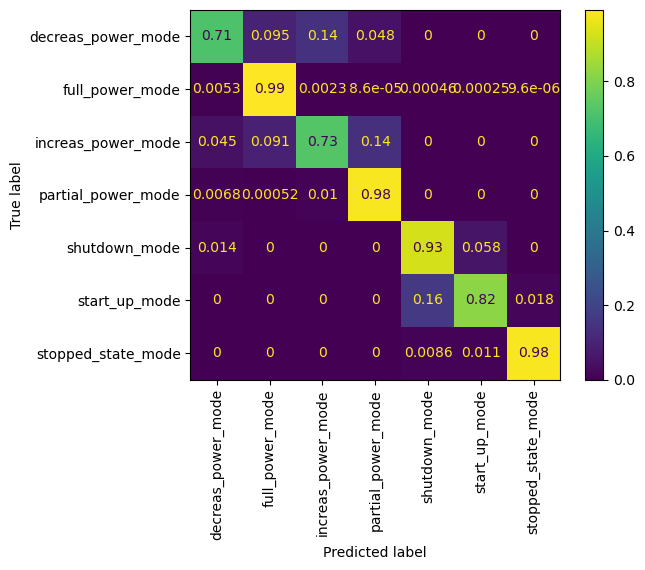

In [28]:
conf_mat = confusion_matrix(y_test_eval_encoded, y_pred_base, normalize='true')
ConfusionMatrixDisplay(conf_mat, display_labels=encoder.classes_).plot()
plt.xticks(rotation=90)
plt.show()


In [29]:
print(classification_report(y_test_eval_encoded, y_pred_base, target_names=encoder.classes_))

accuracy_classifier = {}
precision_classifier = {}
recall_classifier = {}
f1_classifier = {}

accuracy_classifier['xgb_base'] = accuracy_score(y_test_eval_encoded, y_pred_base)
precision_classifier['xgb_base'] = precision_score(y_test_eval_encoded, y_pred_base, average='macro', zero_division=np.nan)
recall_classifier['xgb_base'] = recall_score(y_test_eval_encoded, y_pred_base, average='macro', zero_division=np.nan)
f1_classifier['xgb_base'] = f1_score(y_test_eval_encoded, y_pred_base, average='macro', zero_division=np.nan)

print(f"accuracy - {accuracy_classifier['xgb_base']*100:0.2f}%")
print(f"precision - {precision_classifier['xgb_base']*100:0.2f}%")
print(f"recall - {recall_classifier['xgb_base']*100:0.2f}%")
print(f"f1 - {f1_classifier['xgb_base']*100:0.2f}%")


                    precision    recall  f1-score   support

decreas_power_mode       0.01      0.71      0.03        21
   full_power_mode       1.00      0.99      1.00    209021
increas_power_mode       0.03      0.73      0.06        22
partial_power_mode       0.99      0.98      0.99      1909
     shutdown_mode       0.30      0.93      0.45        69
     start_up_mode       0.28      0.82      0.42        55
stopped_state_mode       1.00      0.98      0.99      5323

          accuracy                           0.99    216420
         macro avg       0.52      0.88      0.56    216420
      weighted avg       1.00      0.99      1.00    216420

accuracy - 99.11%
precision - 51.54%
recall - 87.74%
f1 - 56.03%


### Подбор значений гиперпараметров
**RandomizedSearchCV**

In [30]:
target_class_names = ['full_power_mode', 'stopped_state_mode', 'partial_power_mode']
class_to_id = {name: idx for idx, name in enumerate(encoder.classes_)}

sampling_strategy_cv = {
    class_to_id[name]: 1000
    for name in target_class_names
    if name in class_to_id
}

xgb_pipeline = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=sampling_strategy_cv, random_state=42)),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(encoder.classes_),
        eval_metric='mlogloss',
        random_state=42,
    )),
])

param_grid = {
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__n_estimators': [100, 200],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

random_search.fit(X_train, y_train_encoded)

print('Лучшие параметры:', random_search.best_params_)
print('Лучший CV f1_macro:', round(random_search.best_score_, 4))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры: {'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8}
Лучший CV f1_macro: 0.5616


In [31]:
# Оценка модели на тестовых данных
best_classifier = random_search.best_estimator_
y_pred_tuned = best_classifier.predict(X_test_eval)


### Анализ качества модели

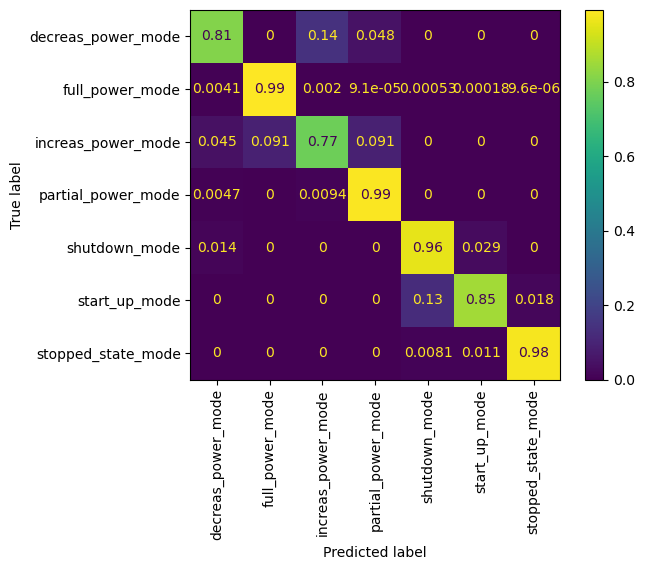

In [32]:
conf_mat = confusion_matrix(y_test_eval_encoded, y_pred_tuned, normalize='true')
ConfusionMatrixDisplay(conf_mat, display_labels=encoder.classes_).plot()
plt.xticks(rotation=90)
plt.show()


In [33]:
print(classification_report(y_test_eval_encoded, y_pred_tuned, target_names=encoder.classes_))

accuracy_classifier['xgb_tuned'] = accuracy_score(y_test_eval_encoded, y_pred_tuned)
precision_classifier['xgb_tuned'] = precision_score(y_test_eval_encoded, y_pred_tuned, average='macro', zero_division=np.nan)
recall_classifier['xgb_tuned'] = recall_score(y_test_eval_encoded, y_pred_tuned, average='macro', zero_division=np.nan)
f1_classifier['xgb_tuned'] = f1_score(y_test_eval_encoded, y_pred_tuned, average='macro', zero_division=np.nan)

pd.DataFrame({
    'accuracy': accuracy_classifier,
    'precision': precision_classifier,
    'recall': recall_classifier,
    'f1': f1_classifier,
}).T


                    precision    recall  f1-score   support

decreas_power_mode       0.02      0.81      0.04        21
   full_power_mode       1.00      0.99      1.00    209021
increas_power_mode       0.04      0.77      0.07        22
partial_power_mode       0.99      0.99      0.99      1909
     shutdown_mode       0.29      0.96      0.45        69
     start_up_mode       0.32      0.85      0.47        55
stopped_state_mode       1.00      0.98      0.99      5323

          accuracy                           0.99    216420
         macro avg       0.52      0.91      0.57    216420
      weighted avg       1.00      0.99      1.00    216420



,xgb_base,xgb_tuned
accuracy,0.991138,0.992653
precision,0.515384,0.522810
recall,0.877385,0.907615
f1,0.560279,0.571315


## Прогнозирование с XGBoost

In [34]:
# import gdown
# import warnings
# warnings.filterwarnings('ignore')
# url = "https://drive.google.com/drive/folders/1RtrAevJUYSgTbp0YUztxEBB8_VcvjgGH?usp=drive_link"
# gdown.download_folder(url, quiet=True, verify=False)

In [35]:
import glob
parquetFileList = glob.glob(f'./option_0/*.gzip')

In [36]:
df_list = []

for file in tqdm(parquetFileList):
    df = pd.read_parquet(file)
    df_list.append(df)

data = pd.concat(df_list, axis=0).sort_index().ffill().drop_duplicates()
data = data.dropna()

100%|█████████████████████████████████████████████| 8/8 [00:00<00:00, 34.26it/s]


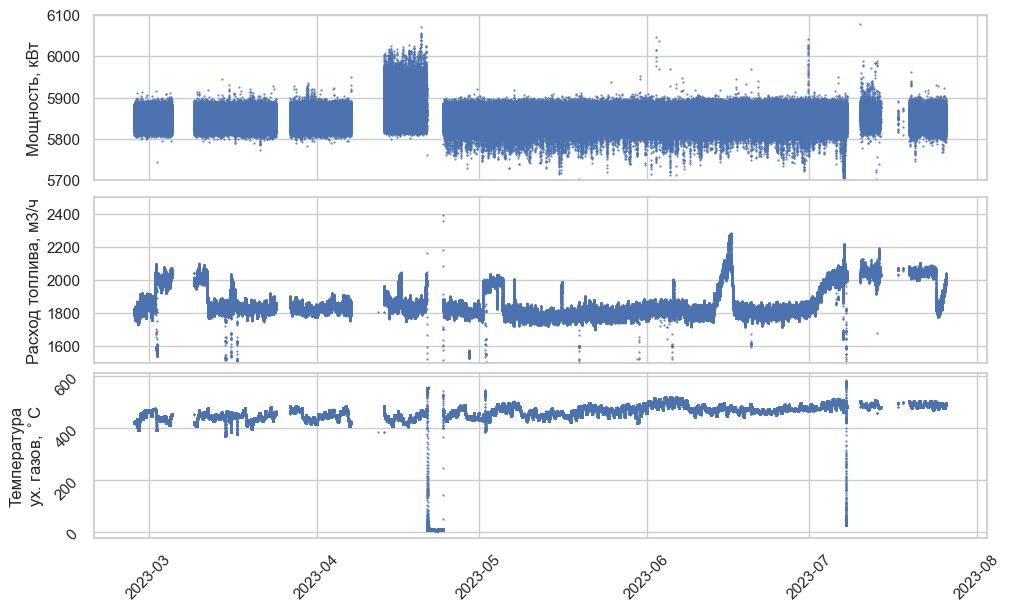

In [37]:
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 6), constrained_layout=True)

ax1.plot(data['GTA1.DBinPU.P'].index, data['GTA1.DBinPU.P'].values,
         linestyle='none', marker='.', markersize=1);
ax1.set_ylabel("Мощность, кВт");
ax1.set_ylim([5700,6100]);
ax1.tick_params(labelbottom=False)

ax2.plot(data['GTA1.DBinPU.Qtg'].index, data['GTA1.DBinPU.Qtg'].values,
         linestyle='none', marker='.', markersize=1);
ax2.set_ylabel("Расход топлива, м3/ч");
ax2.set_ylim([1500,2500]);
ax2.tick_params(labelbottom=False)

ax3.plot(data['GTA1.DBinPU.Tt'].index, data['GTA1.DBinPU.Tt'].values,
         linestyle='none', marker='.', markersize=1);
ax3.set_ylabel("Температура\nух. газов, $^\\circ$С");
# ax3.set_ylim([300,600]);
ax3.tick_params(rotation=45);

### Предобработка данных

Проредим и отфильтруем данные


In [38]:
df = pd.DataFrame(data['GTA1.DBinPU.Tt'])
df = df.resample('1h').mean()
df.columns = ['Tt']
df = df[df['Tt'] > 300]
df = df.resample('1h').asfreq()

In [39]:
df.shape

(3601, 1)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3601 entries, 2023-02-26 06:00:00 to 2023-07-26 06:00:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Tt      3050 non-null   float64
dtypes: float64(1)
memory usage: 56.3 KB


In [41]:
df[df['Tt'].isna()]

,Tt
2023-03-05 06:00:00,NaN
2023-03-05 07:00:00,NaN
2023-03-05 08:00:00,NaN
2023-03-05 09:00:00,NaN
2023-03-05 10:00:00,NaN
...,...
2023-07-19 04:00:00,NaN
2023-07-19 05:00:00,NaN
2023-07-19 06:00:00,NaN
2023-07-19 07:00:00,NaN


In [42]:
df.index.to_series().diff().max()

Timedelta('0 days 01:00:00')

In [43]:
df.loc['2023-03-05 01:00:00':'2023-03-05 08:00:00']

,Tt
2023-03-05 01:00:00,442.195003
2023-03-05 02:00:00,444.122162
2023-03-05 03:00:00,447.556457
2023-03-05 04:00:00,452.478640
2023-03-05 05:00:00,455.739461
2023-03-05 06:00:00,NaN
2023-03-05 07:00:00,NaN
2023-03-05 08:00:00,NaN


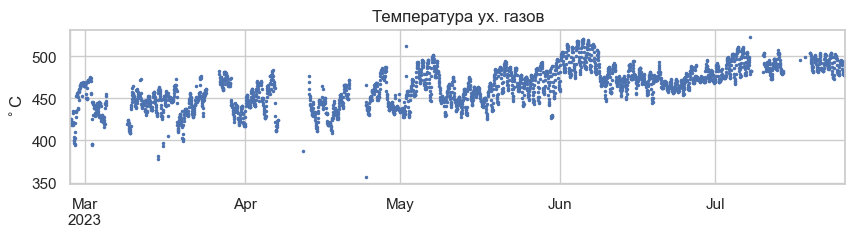

In [44]:
df.plot(style='.', figsize=(10, 2), ms=3, title="Температура ух. газов", legend=False)
plt.ylabel("$^\\circ$С")
plt.show()

**Лаги** — это **значения временного ряда на предыдущих временных шагах**, которые используются как признаки (фичи) для предсказания будущих значений.

Функция для генерации лагов

In [45]:
def create_lag_features(df, column, lags):
    """
    Создает лаги признака column в количестве lags и возвращает новый DataFrame.
    """
    df_lagged = df.copy()
    for lag in range(1, lags + 1):
        df_lagged[f"{column}_lag_{lag}"] = df_lagged[column].shift(lag)

    return df_lagged

In [46]:
n_lags = 24
df = create_lag_features(df, 'Tt', n_lags)

In [47]:
df.index.to_series().diff().max()

Timedelta('0 days 01:00:00')

In [48]:
df.shape

(3601, 25)

In [49]:
df.head()

,Tt,Tt_lag_1,Tt_lag_2,Tt_lag_3,Tt_lag_4,Tt_lag_5,Tt_lag_6,Tt_lag_7,Tt_lag_8,Tt_lag_9,...,Tt_lag_15,Tt_lag_16,Tt_lag_17,Tt_lag_18,Tt_lag_19,Tt_lag_20,Tt_lag_21,Tt_lag_22,Tt_lag_23,Tt_lag_24
2023-02-26 06:00:00,418.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-26 07:00:00,421.854112,418.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-26 08:00:00,425.267525,421.854112,418.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-26 09:00:00,425.640959,425.267525,421.854112,418.800000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-26 10:00:00,422.100007,425.640959,425.267525,421.854112,418.8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
df.dropna(inplace=True)

Создаем вектор признаков и вектор целевых значений


In [51]:
y = df.loc[:, ['Tt']]
X = df.loc[:, [col for col in df.columns if 'lag' in col]]


Разделим на тренировочную и тестовую выборки (**временной порядок важно сохранить!**)

In [52]:
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

assert X.index.is_monotonic_increasing
assert y.index.is_monotonic_increasing
assert X.index.is_unique
assert y.index.is_unique
assert X_train.index.max() < X_test.index.min()
assert y_train['Tt'].notna().all() and y_test['Tt'].notna().all()


### Инициализация и обучение модели

In [53]:
pred_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
pred_model.fit(X_train, y_train.values.ravel())


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Предсказание и базовые ориентиры

В этой ячейке считаются прогнозы основной модели XGBoost на тестовой выборке (y_pred), а также два простых baseline-прогноза для сравнения качества:

- baseline_mean_pred — среднее значение признаков в строке теста.
- baseline_lag1_pred — значение лагового признака Tt_lag_1 (наивный прогноз "как в предыдущий момент").

Далее эти три варианта будут сопоставляться по метрикам ошибки.


In [54]:
y_pred = pred_model.predict(X_test)

baseline_mean_pred = X_test.mean(axis=1).values
baseline_lag1_pred = X_test['Tt_lag_1'].values


### Анализ качества модели

In [55]:
def mape_nonzero(y_true, y_pred, eps=1e-6):
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan, 100.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100, 100 * (1 - mask.mean())


def smape(y_true, y_pred, eps=1e-6):
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100


def wape(y_true, y_pred, eps=1e-6):
    return (np.abs(y_true - y_pred).sum() / (np.abs(y_true).sum() + eps)) * 100


def evaluate_regression(y_true, y_pred):
    mape_val, excl = mape_nonzero(y_true, y_pred)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape_val,
        'sMAPE': smape(y_true, y_pred),
        'WAPE': wape(y_true, y_pred),
        'MAPE_excluded_%': excl,
    }


y_true = y_test['Tt'].values

metrics_one_step = pd.DataFrame([
    {'model': 'xgb', **evaluate_regression(y_true, y_pred)},
    {'model': 'baseline_mean', **evaluate_regression(y_true, baseline_mean_pred)},
    {'model': 'baseline_lag1', **evaluate_regression(y_true, baseline_lag1_pred)},
]).set_index('model')

metrics_one_step


,MAE,RMSE,MAPE,sMAPE,WAPE,MAPE_excluded_%
model,,,,,,
xgb,2.003075,2.820599,0.413450,0.413747,0.414708,0.0
baseline_mean,7.015326,8.479549,1.446200,1.447029,1.452424,0.0
baseline_lag1,2.121927,3.031983,0.438277,0.438232,0.439315,0.0


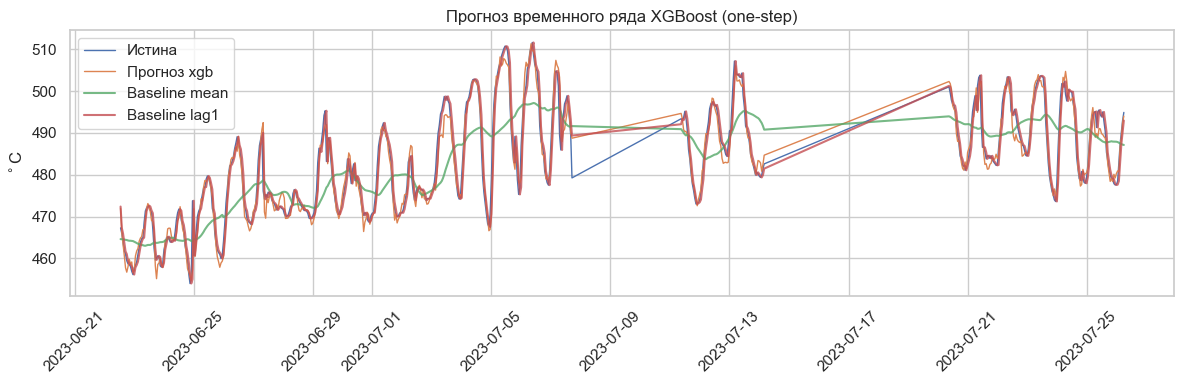

In [56]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.index, y_test['Tt'].values, label='Истина', linewidth=1)
plt.plot(y_test.index, y_pred, label='Прогноз xgb', linewidth=1)
plt.plot(y_test.index, baseline_mean_pred, label='Baseline mean', alpha=0.8)
plt.plot(y_test.index, baseline_lag1_pred, label='Baseline lag1', alpha=0.8)

plt.legend()
plt.title('Прогноз временного ряда XGBoost (one-step)')
plt.ylabel('$^\circ$С')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Автономный авторегрессионный прогноз (одна точка за раз)
На вход модели подаются предсказания, а не истинные значения из данных

In [57]:
start = X_test.index[0]
end = X_test.index[-1]
timestamps = pd.date_range(start=start, end=end, freq='1h')


In [58]:
predictions = []
lags = X_test.iloc[0].values.tolist()  # первые лаги из начала теста

for _ in timestamps:
    y_hat = pred_model.predict(np.array([lags]))[0]
    predictions.append(y_hat)
    lags = lags[1:] + [y_hat]

predictions = pd.DataFrame(predictions, index=timestamps, columns=['Tt'])

baseline_predictions = [X_test.iloc[0].mean() for _ in y_test.index]


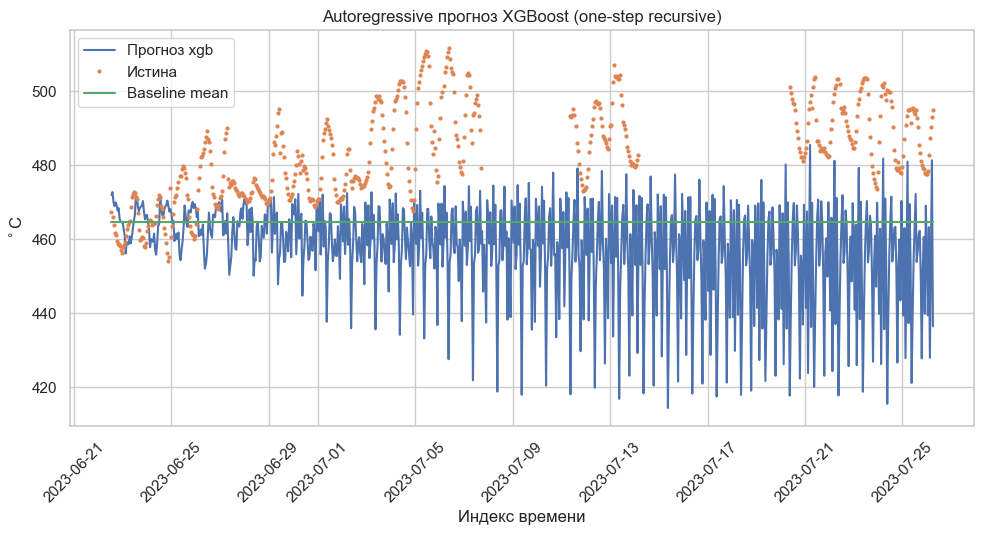

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(timestamps, predictions['Tt'], label='Прогноз xgb')
plt.plot(df['Tt'].loc[start:].index, df['Tt'].loc[start:], linestyle='none', marker='.', markersize=4, label='Истина')
plt.plot(y_test.index, baseline_predictions, label='Baseline mean')

plt.ylabel('$^\circ$С')
plt.title('Autoregressive прогноз XGBoost (one-step recursive)')
plt.xlabel('Индекс времени')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [60]:
# Общие индексы
common_index = y_test.index.intersection(predictions.index)

In [62]:
common_index = y_test.index.intersection(predictions.index)

y_true_ar = y_test.loc[common_index, 'Tt'].values
y_pred_ar = predictions.loc[common_index, 'Tt'].values
baseline_ar = np.array(baseline_predictions)[:len(common_index)]

pd.DataFrame([
    {'model': 'xgb_recursive', **evaluate_regression(y_true_ar, y_pred_ar)},
    {'model': 'baseline_mean_recursive', **evaluate_regression(y_true_ar, baseline_ar)},
]).set_index('model')


,MAE,RMSE,MAPE,sMAPE,WAPE,MAPE_excluded_%
model,,,,,,
xgb_recursive,25.321811,31.038215,5.171579,5.377363,5.242521,0.0
baseline_mean_recursive,19.025298,22.328469,3.879803,3.983936,3.938917,0.0


### Модель с множественным прогнозом (сразу n точек)

**sequence-to-sequence (seq2seq)** прогноз с XGBoost.
Модель получает на вход `input_len` прошлых значений и предсказывает сразу `output_len` будущих.

XGBoost **не поддерживает** напрямую многомерный выход, поэтому используем `MultiOutputRegressor`.


In [63]:
def make_seq2seq_dataset(series, input_len, output_len):
    X, Y = [], []
    for i in range(len(series) - input_len - output_len + 1):
        x_temp = series[i:i + input_len]
        y_temp = series[i + input_len:i + input_len + output_len]

        if x_temp.isna().any() or y_temp.isna().any():
            continue

        X.append(x_temp.values)
        Y.append(y_temp.values)

    return np.array(X), np.array(Y)


In [64]:
input_len = 20
output_len = 20
X, Y = make_seq2seq_dataset(
    df.resample('1h').asfreq()['Tt'],
    input_len=input_len, output_len=output_len)

In [65]:
X.shape, Y.shape

((2600, 20), (2600, 20))

In [66]:
X[0], Y[0]

(array([427.89169961, 433.45389439, 434.94451665, 435.40380167,
        452.94766703, 454.6168376 , 454.40054413, 455.43322453,
        456.80061197, 457.22453176, 451.90051803, 437.10264479,
        438.0155521 , 438.84740899, 448.09704101, 457.74038463,
        458.33222729, 460.54684883, 461.6638904 , 462.96702211]),
 array([464.60678181, 464.66273943, 465.77189343, 467.35231664,
        468.44005511, 468.42795843, 467.4678937 , 466.24691994,
        452.43033483, 466.21960405, 465.93509197, 465.97525023,
        467.48868378, 468.46202658, 468.46600245, 468.75017976,
        469.72054105, 465.39873324, 464.57180178, 464.67390051]))

Разделение на тестовую и тренировочную выборки

In [67]:
train_size = int(len(Y) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

`MultiOutputRegressor`

Это обёртка, которая позволяет использовать обычную регрессионную модель
(например, `XGBRegressor`) для задач многомерной регрессии.


In [68]:
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
))
model.fit(X_train, y_train)


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [69]:
y_pred = model.predict(X_test)

In [70]:
baseline_pred = np.array([np.ones(output_len) * x.mean() for x in X_test])


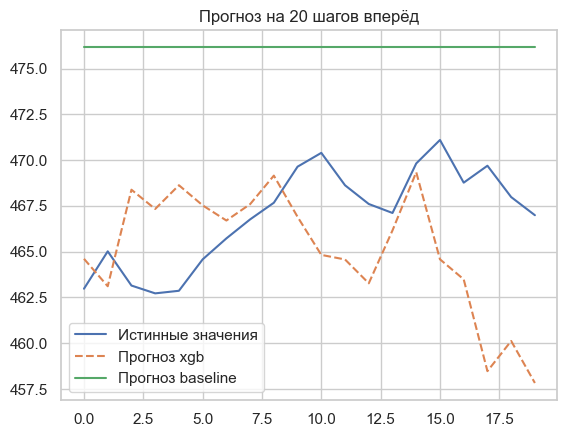

In [71]:
sample = 0

plt.plot(range(output_len), y_test[sample], label="Истинные значения")
plt.plot(range(output_len), y_pred[sample], label="Прогноз xgb", linestyle="--")
plt.plot(range(output_len), baseline_pred[sample], label='Прогноз baseline')
plt.legend()
plt.title(f"Прогноз на {output_len} шагов вперёд")
plt.show()

In [72]:
# np.sqrt(mean_squared_error(y_test[0], y_pred[0]))

In [73]:
# np.sqrt(mean_squared_error(y_test[0], baseline_pred[0]))

In [74]:
y_true_seq2seq = y_test.reshape(-1)
y_pred_seq2seq = y_pred.reshape(-1)
baseline_seq2seq = baseline_pred.reshape(-1)

pd.DataFrame([
    {'model': 'xgb_seq2seq', **evaluate_regression(y_true_seq2seq, y_pred_seq2seq)},
    {'model': 'baseline_mean_seq2seq', **evaluate_regression(y_true_seq2seq, baseline_seq2seq)},
]).set_index('model')


,MAE,RMSE,MAPE,sMAPE,WAPE,MAPE_excluded_%
model,,,,,,
xgb_seq2seq,8.026396,10.882860,1.657140,1.678869,1.668387,0.0
baseline_mean_seq2seq,7.266902,9.056864,1.499528,1.503667,1.510517,0.0


### Автономный авторегрессионный прогноз с seq2seq моделью


In [75]:
# Индекс начала первого тестового горизонта в исходном ряде
start_idx = train_size + input_len
start = df.index[start_idx]
timestamps = df.index[start_idx:]


In [76]:
current_input = X_test[0].copy()
predictions = []

# Число итераций так, чтобы покрыть весь хвост ряда
n_iters = int(np.ceil(len(timestamps) / output_len))


In [77]:
for _ in range(n_iters):
    pred = model.predict(np.array([current_input]))[0]
    predictions.extend(pred.tolist())
    current_input = np.concatenate([current_input, pred])[-input_len:]


In [78]:
predictions = predictions[:len(timestamps)]
predictions = pd.DataFrame(predictions, index=timestamps, columns=['Tt'])


In [79]:
common_index = df.index.intersection(predictions.index)


In [80]:
baseline_predictions = [X_test[0].mean() for _ in common_index]


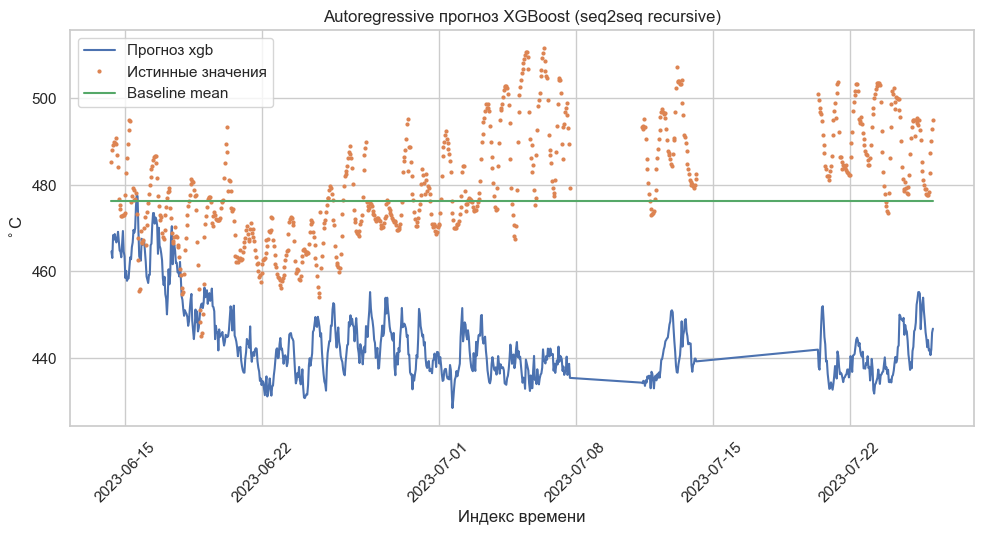

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(predictions.index, predictions['Tt'], label='Прогноз xgb')
plt.plot(
    df['Tt'].loc[common_index].index,
    df['Tt'].loc[common_index].values,
    linestyle='none',
    marker='.',
    markersize=4,
    label='Истинные значения',
)
plt.plot(df['Tt'].loc[common_index].index, baseline_predictions, label='Baseline mean')

plt.ylabel('$^\circ$С')
plt.title('Autoregressive прогноз XGBoost (seq2seq recursive)')
plt.xlabel('Индекс времени')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [82]:
y_true_seq2seq_recursive = df.loc[common_index, 'Tt'].values
y_pred_seq2seq_recursive = predictions.loc[common_index, 'Tt'].values
baseline_seq2seq_recursive = np.array(baseline_predictions)

pd.DataFrame([
    {'model': 'xgb_seq2seq_recursive', **evaluate_regression(y_true_seq2seq_recursive, y_pred_seq2seq_recursive)},
    {'model': 'baseline_mean_seq2seq_recursive', **evaluate_regression(y_true_seq2seq_recursive, baseline_seq2seq_recursive)},
]).set_index('model')


,MAE,RMSE,MAPE,sMAPE,WAPE,MAPE_excluded_%
model,,,,,,
xgb_seq2seq_recursive,36.416364,40.084457,7.510343,7.864120,7.583663,0.0
baseline_mean_seq2seq_recursive,10.663640,13.444478,2.199364,2.218562,2.220690,0.0
